In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv(r"C:\Users\SRINITHI S\Downloads\Team13_ML\data\garments_worker_productivity.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1197, 15)


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistics:")
display(df.describe())

Columns:
['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']

Data Types:


date                         str
quarter                      str
department                   str
day                          str
team                       int64
targeted_productivity    float64
smv                      float64
wip                      float64
over_time                  int64
incentive                  int64
idle_time                float64
idle_men                   int64
no_of_style_change         int64
no_of_workers            float64
actual_productivity      float64
dtype: object


Missing Values:


date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64


Duplicate Rows: 0

Statistics:


,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [6]:
df_clean = df.copy()

# Numerical columns
numeric_features = df_clean.select_dtypes(include=np.number).columns.tolist()

# Remove target
numeric_features.remove("actual_productivity")

# Fill numerical missing values
for col in numeric_features:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].median()
    )

# Categorical columns
categorical_features = df_clean.select_dtypes(
    include="object"
).columns.tolist()

# Fill categorical missing values
for col in categorical_features:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].mode()[0]
    )

# Remove duplicates
df_clean = df_clean.drop_duplicates()

print("Remaining missing values:",
      df_clean.isnull().sum().sum())

print("Remaining duplicates:",
      df_clean.duplicated().sum())

Remaining missing values: 0
Remaining duplicates: 0


C:\Users\SRINITHI S\AppData\Local\Temp\ipykernel_20176\1063645473.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df_clean.select_dtypes(


In [7]:
df_clean["overtime_per_worker"] = (
    df_clean["over_time"] /
    df_clean["no_of_workers"].replace(0, np.nan)
)

df_clean["overtime_per_worker"] = (
    df_clean["overtime_per_worker"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("Feature engineering completed.")

display(
    df_clean[
        [
            "over_time",
            "no_of_workers",
            "overtime_per_worker"
        ]
    ].head()
)

Feature engineering completed.


,over_time,no_of_workers,overtime_per_worker
0,7080,59.0,120.000000
1,960,8.0,120.000000
2,3660,30.5,120.000000
3,3660,30.5,120.000000
4,1920,56.0,34.285714


In [8]:
X = df_clean.drop(
    columns=["actual_productivity"]
)

y = df_clean["actual_productivity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1197, 15)
y shape: (1197,)


In [9]:
X = df_clean.drop(
    columns=["actual_productivity"]
)

y = df_clean["actual_productivity"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1197, 15)
y shape: (1197,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (957, 15)
Testing data: (240, 15)


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [12]:
results = []

print("Results list created.")

Results list created.


In [13]:
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=RANDOM_STATE
            )
        )
    ]
)

dt_params = {
    "model__max_depth": [
        3, 5, 7, 10, 15, None
    ]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    dt_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

dt_pred = dt_grid.predict(X_test)

dt_r2 = r2_score(y_test, dt_pred)
dt_rmse = np.sqrt(
    mean_squared_error(y_test, dt_pred)
)
dt_mae = mean_absolute_error(
    y_test,
    dt_pred
)

print("Best parameters:")
print(dt_grid.best_params_)

print("\nDecision Tree Regressor")
print("----------------------")
print("R²   :", dt_r2)
print("RMSE :", dt_rmse)
print("MAE  :", dt_mae)

Best parameters:
{'model__max_depth': 5}

Decision Tree Regressor
----------------------
R²   : 0.338999637212804
RMSE : 0.13248090430325402
MAE  : 0.08652991707042439


In [14]:
dt_model = dt_grid.best_estimator_.named_steps["model"]

feature_names = (
    dt_grid
    .best_estimator_
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df.head(15))

,Feature,Importance
1,num__targeted_productivity,0.412518
5,num__incentive,0.173984
2,num__smv,0.156452
9,num__no_of_workers,0.069622
72,cat__quarter_Quarter4,0.044058
3,num__wip,0.037331
7,num__idle_men,0.030302
75,cat__department_finishing,0.025717
69,cat__quarter_Quarter1,0.022340
0,num__team,0.015989


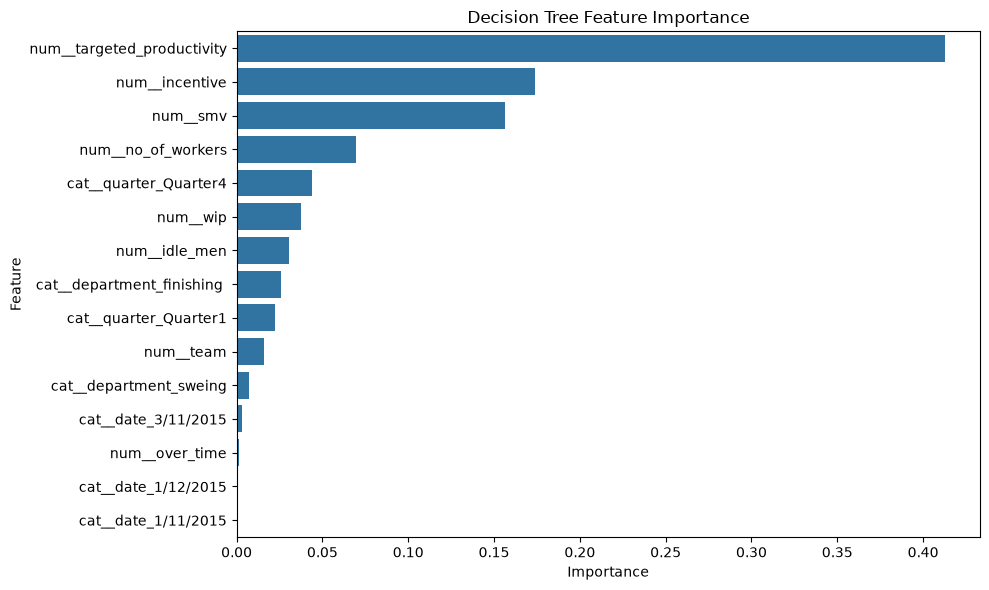

In [15]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Decision Tree Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()